100%|██████████| 12000/12000 [01:22<00:00, 144.88it/s]


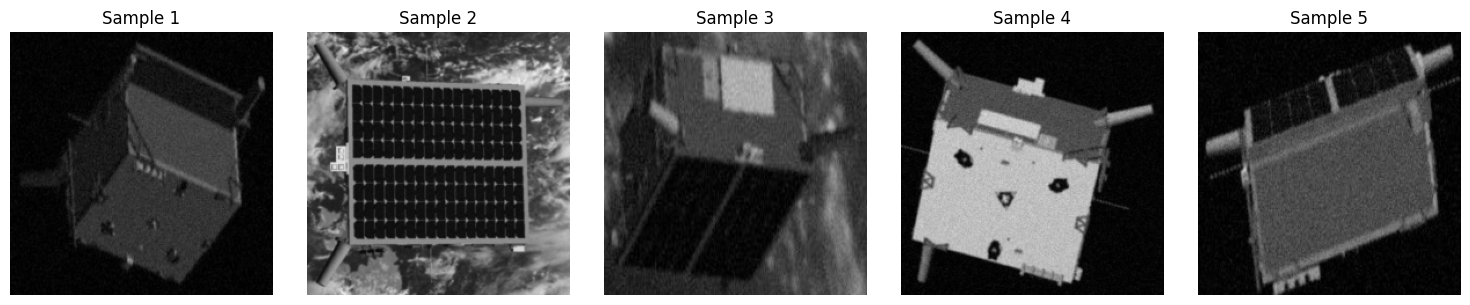

/tmp/ipykernel_19/1202243453.py:647: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Layer (type:depth-idx)                   Output Shape              Param #
SPN                                      [1, 5000]                 --
├─Conv2d: 1-1                            [1, 96, 55, 55]           34,944
├─MaxPool2d: 1-2                         [1, 96, 27, 27]           --
├─LocalResponseNorm: 1-3                 [1, 96, 27, 27]           --
├─Conv2d: 1-4                            [1, 256, 27, 27]          307,456
├─MaxPool2d: 1-5                         [1, 256, 13, 13]          --
├─LocalResponseNorm: 1-6                 [1, 256, 13, 13]          --
├─Conv2d: 1-7                            [1, 384, 13, 13]          885,120
├─Conv2d: 1-8                            [1, 384, 13, 13]          663,936
├─Conv2d: 1-9                            [1, 256, 13, 13]          442,624
├─MaxPool2d: 1-10                        [1, 256, 6, 6]            --
├─Linear: 1-11                           [1, 4096]                 37,752,832
├─Dropout: 1-12                          [1, 4096]   

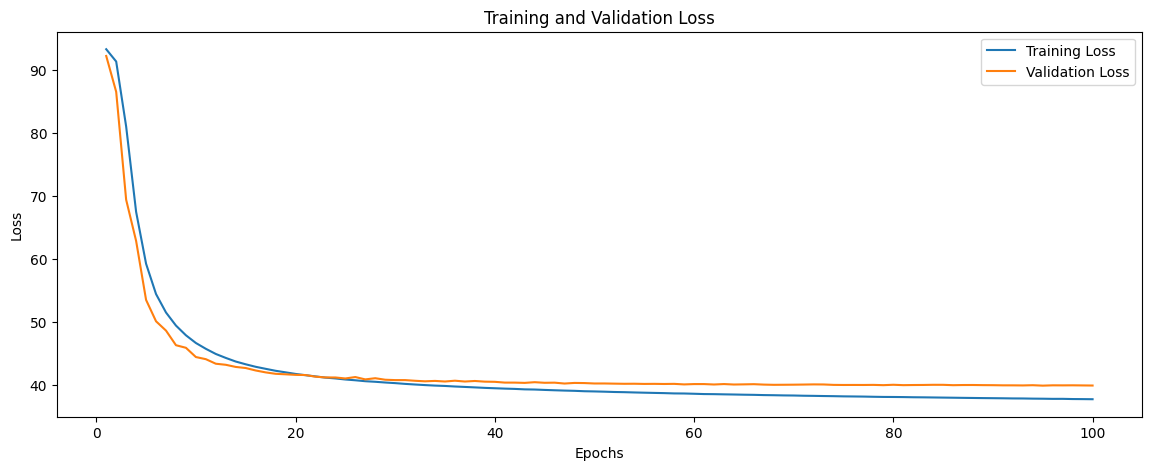

In [1]:
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch import nn,optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.functional as T
from torchinfo import summary
from scipy.io import loadmat
from scipy.spatial.transform import Rotation as R
from torch.amp import autocast
from torch.cuda.amp import GradScaler
import numpy as np
import tqdm



def get_discrete_classes(m):
    """
    Computes m uniformly distributed random rotations parametrized as unit quaternions.
    
    Args:
        m (int): Number of random rotations to generate
        
    Returns:
        numpy.ndarray: Matrix of shape (m, 4) containing unit quaternions
    """
    x0 = np.random.rand(m)
    x1 = np.random.rand(m)
    x2 = np.random.rand(m)
    
    
    theta1 = 2 * np.pi * x1
    theta2 = 2 * np.pi * x2
    
    
    s1 = np.sin(theta1)
    s2 = np.sin(theta2)
    c1 = np.cos(theta1)
    c2 = np.cos(theta2)
    
    
    r1 = np.sqrt(1 - x0)
    r2 = np.sqrt(x0)
    
    
    quats = np.column_stack([s1 * r1, c1 * r1, s2 * r2, c2 * r2])
    
    return quats

def _get_quat_bins(qPose, qClass, numNeighbors):
    ''' For each quaternion in `qPose`, find the nearest quaternion in `qClass` and
        the weights associated with distance to each class. Based on the original MATLAB 
        implementation by Sumant Sharma.
    Arguments:
        qPose:  (4,)  array of unit quaternion (scalar-first)
        qClass: (N,4) matrix of unit quaternion classes (scalar-first)
        numNeighbors: (int) number of `qClass` covering each of `qOise`
    Returns:
        nClasses: (numNeighbors,) array of closest quaternion classes
        nWeights: (numNeighbors,) array of weights of each quaternion classes
    '''
    # Quaternion classes into scalar-last for scipy
    q      = R.from_quat(qPose[[1,2,3,0]])
    qClass = R.from_quat(qClass[:,[1,2,3,0]])

    # Orientation diff. w.r.t. each entries in qClass [numClasses, 4]
    qDiff = q.inv() * qClass
    qDiff = qDiff.as_quat()

    # Angular distance w.r.t. each entries of qClass [rad]
    angleVec = 2 * np.arccos(np.abs(qDiff[:,-1])) # scalar-last

    # nAngles:  Smallest angular distances [rad]
    # nCLasses: Class indices of such entries
    sortIdx  = np.argsort(angleVec)
    nClasses = sortIdx[:numNeighbors]
    nAngles  = angleVec[nClasses]

    # Angular distances into weights
    nWeights = 1.0 - nAngles / np.pi**2 # (numNeighbors,)
    nWeights = nWeights / np.sum(nWeights)

    return nClasses, nWeights

def softmax_cross_entropy_with_logits(logits, target, reduction='mean'):
    """ Implementation of tensorflow's function of the same name
        - logits [B x C]
        - target [B x C]
    """
    loss = -torch.sum(target.detach() * F.log_softmax(logits, dim=1), dim=1) # [B,]
    if reduction == 'mean':
        return loss.mean()
    elif reduction == 'sum':
        return loss.sum()
    else:
        return loss

def load_tango_3d_keypoints(mat_dir):
    vertices  = loadmat(mat_dir)['tango3Dpoints'] # [3 x 11]
    corners3D = np.transpose(np.array(vertices, dtype=np.float32)) # [11 x 3]

    return corners3D

def load_camera_intrinsics(camera_json):
    with open(camera_json) as f:
        cam = json.load(f)
    cameraMatrix = np.array(cam['cameraMatrix'], dtype=np.float32)
    distCoeffs   = np.array(cam['distCoeffs'],   dtype=np.float32)

    return cameraMatrix, distCoeffs

def quat2dcm(q):
    """ Computing direction cosine matrix from quaternion, adapted from PyNav.
    Arguments:
        q: (4,) numpy.ndarray - unit quaternion (scalar-first)
    Returns:
        dcm: (3,3) numpy.ndarray - corresponding DCM
    """

    # normalizing quaternion
    q = q/np.linalg.norm(q)

    q0 = q[0]
    q1 = q[1]
    q2 = q[2]
    q3 = q[3]

    dcm = np.zeros((3, 3))

    dcm[0, 0] = 2 * q0 ** 2 - 1 + 2 * q1 ** 2
    dcm[1, 1] = 2 * q0 ** 2 - 1 + 2 * q2 ** 2
    dcm[2, 2] = 2 * q0 ** 2 - 1 + 2 * q3 ** 2

    dcm[0, 1] = 2 * q1 * q2 + 2 * q0 * q3
    dcm[0, 2] = 2 * q1 * q3 - 2 * q0 * q2

    dcm[1, 0] = 2 * q1 * q2 - 2 * q0 * q3
    dcm[1, 2] = 2 * q2 * q3 + 2 * q0 * q1

    dcm[2, 0] = 2 * q1 * q3 + 2 * q0 * q2
    dcm[2, 1] = 2 * q2 * q3 - 2 * q0 * q1

    return dcm

def project_keypoints(q_vbs2tango, r_Vo2To_vbs, cameraMatrix, distCoeffs, keypoints):
    ''' Project keypoints.
    Arguments:
        q_vbs2tango:  (4,) numpy.ndarray - unit quaternion from VBS to Tango frame
        r_Vo2To_vbs:  (3,) numpy.ndarray - position vector from VBS to Tango in VBS frame (m)
        cameraMatrix: (3,3) numpy.ndarray - camera intrinsics matrix
        distCoeffs:   (5,) numpy.ndarray - camera distortion coefficients in OpenCV convention
        keypoints:    (3,N) or (N,3) numpy.ndarray - 3D keypoint locations (m)
    Returns:
        points2D: (2,N) numpy.ndarray - projected points (pix)
    '''
    # Size check (3,N)
    if keypoints.shape[0] != 3:
        keypoints = np.transpose(keypoints)

    # Keypoints into 4 x N homogenous coordinates
    keypoints = np.vstack((keypoints, np.ones((1, keypoints.shape[1]))))

    # transformation to image frame
    pose_mat = np.hstack((np.transpose(quat2dcm(q_vbs2tango)),
                          np.expand_dims(r_Vo2To_vbs, 1)))
    xyz      = np.dot(pose_mat, keypoints) # [3 x N]
    x0, y0   = xyz[0,:] / xyz[2,:], xyz[1,:] / xyz[2,:] # [1 x N] each

    # apply distortion
    r2 = x0*x0 + y0*y0
    cdist = 1 + distCoeffs[0]*r2 + distCoeffs[1]*r2*r2 + distCoeffs[4]*r2*r2*r2
    x  = x0*cdist + distCoeffs[2]*2*x0*y0 + distCoeffs[3]*(r2 + 2*x0*x0)
    y  = y0*cdist + distCoeffs[2]*(r2 + 2*y0*y0) + distCoeffs[3]*2*x0*y0

    # apply camera matrix
    points2D = np.vstack((cameraMatrix[0,0]*x + cameraMatrix[0,2],
                          cameraMatrix[1,1]*y + cameraMatrix[1,2]))

    return points2D

class Speed(Dataset):
    def __init__(self, images_dir, json_dir, transform=None):
        self.images_dir = images_dir
        self.json_dir = json_dir
        self.transform = transform

        self.num_classes = 5000
        self.num_neighbors = 25

        self.imagesList = []
        self.yClassesList = []
        self.yWeightsList = []
        self.bboxList = []
        self.keyptsList = []

        cnt=0

        # attClassesMAT =   get_discrete_classes(self.num_classes)
        attClassesMAT = loadmat('/kaggle/input/mat-file/attitudeClasses.mat')['qClass']
        keypts3d = load_tango_3d_keypoints('/kaggle/input/mat-file/tangoPoints.mat') # https://www.desmos.com/3d/jud6lng9gn
        cameraMatrix, distCoeffs = load_camera_intrinsics('/kaggle/input/mat-file/camera.json')

        with open(self.json_dir, 'r') as f:
            annotations = json.load(f)
            lookup = { item['filename']: item for item in annotations }


            for filename in tqdm.tqdm(os.listdir(self.images_dir)):
                if filename not in lookup:
                    continue
                self.imagesList.append(os.path.join(self.images_dir, filename))

                q_vbs2tango = np.array(lookup[filename]["q_vbs2tango"], dtype=np.float32)
                r_Vo2To_vbs = np.array(lookup[filename]['r_Vo2To_vbs_true'], dtype=np.float32)

                [attClasses, attWeights] = _get_quat_bins(q_vbs2tango, attClassesMAT, self.num_neighbors)

                yClasses = np.zeros(self.num_classes, dtype=np.float32)
                yClasses[attClasses] = 1. / self.num_neighbors

                yWeights = np.zeros(self.num_classes, dtype=np.float32)
                yWeights[attClasses] = attWeights

                self.yClassesList.append(torch.from_numpy(yClasses))
                self.yWeightsList.append(torch.from_numpy(yWeights))

                keypts2d = project_keypoints(q_vbs2tango, r_Vo2To_vbs, cameraMatrix, distCoeffs, keypts3d) # (2, 11)
                xmin = np.min(keypts2d[0])
                xmax = np.max(keypts2d[0])
                ymin = np.min(keypts2d[1])
                ymax = np.max(keypts2d[1])


                width = xmax - xmin
                height = ymax - ymin
                margin_x = width * 0.05
                margin_y = height * 0.05

                xmin = max(0, xmin - margin_x)
                xmax = xmax + margin_x
                ymin = max(0, ymin - margin_y)
                ymax = ymax + margin_y

                bbox = [xmin, xmax, ymin, ymax]

                self.bboxList.append(bbox)
                self.keyptsList.append(torch.tensor(keypts2d, dtype=torch.float32))

                cnt=cnt+1
                # if cnt>1000:
                #     break

    def __len__(self):
        return len(self.imagesList)

    def __getitem__(self, idx):
        image_path = self.imagesList[idx]
        image = Image.open(image_path).convert('RGB')
        orig_w, orig_h = image.size
        yClasses = self.yClassesList[idx]
        yWeights = self.yWeightsList[idx]
        bbox = self.bboxList[idx]
        keypts = self.keyptsList[idx]

        if self.transform:
            image, _, _ = self.transform(image, bbox, keypts)

        return image, yClasses, yWeights
    

class Rotate(object):
    ''' Rotate image randomly by 90 deg intervals '''
    def __call__(self, data, bbox, keypts):
        angle = 90*float(torch.randint(1, 4, (1,)))

        # Rotate image
        data = T.rotate(data, angle)

        # Rotate keypoints
        x, y = keypts[0].clone(), keypts[1].clone()
        if angle == 90: # 90 deg
            keypts[0], keypts[1] = y, 1.0 - x
        elif angle == 180: # 180 deg
            keypts[0], keypts[1] = 1.0 - x, 1.0 - y
        elif angle == 270: # 270 deg
            keypts[0], keypts[1] = 1.0 - y, x

        return data, bbox, keypts

class Flip(object):
    ''' Flip image randomly either horizontally or vertically '''
    def __call__(self, data, bbox, keypts):
        if torch.rand(1) < 0.5:
            # horizontal flip
            data = T.hflip(data)
            keypts[0] = 1.0 - keypts[0]
        else:
            # vertical flip
            data = T.vflip(data)
            keypts[1] = 1.0 - keypts[1]

        return data, bbox, keypts

class BrightnessContrast(object):
    """ Adjust brightness and contrast of the image in a fashion of
        OpenCV's convertScaleAbs, where

        newImage = alpha * image + beta

        image: torch.Tensor image (0 ~ 1)
        alpha: multiplicative factor
        beta:  additive factor (0 ~ 255)
    """
    def __init__(self, alpha=(0.5, 2.0), beta=(-25, 25)):
        self.alpha = torch.tensor(alpha).log()
        self.beta  = torch.tensor(beta)/255

    def __call__(self, image, bbox, keypts):
        # Contrast - multiplicative factor
        loga = torch.rand(1) * (self.alpha[1] - self.alpha[0]) + self.alpha[0]
        a = loga.exp()

        # Brightness - additive factor
        b = torch.rand(1) * (self.beta[1]  - self.beta[0])  + self.beta[0]

        # Apply
        image = torch.clamp(a*image + b, 0, 1)

        return image, bbox, keypts

class GaussianNoise(object):
    """ Add random Gaussian white noise

        image: torch.Tensor image (0 ~ 1)
        std:   noise standard deviation (0 ~ 255)
    """
    def __init__(self, std=25):
        self.std = std/255

    def __call__(self, image, bbox, keypts):
        noise = torch.randn(image.shape, dtype=torch.float32) * self.std
        image = torch.clamp(image + noise, 0, 1)
        return image, bbox, keypts

class RandomCrop(object):
    ''' Crop the image with random bounding box fully containing
        the satellite foreground
    '''
    def __init__(self, output_shape, is_train=True):
        self.shape    = output_shape
        self.is_train = is_train

    def __call__(self, image, bbox, keypts):
        # bbox: [xmin, xmax, ymin, ymax] (pix)
        # keypts: [2 x Nk] (pix)
        xmin, xmax, ymin, ymax = bbox
        w, h = xmax-xmin, ymax-ymin
        x, y = xmin+w/2.0, ymin+h/2.0

        # Original image shape
        org_w, org_h = image.size

        # Make sure the RoI is SQUARE, as is most input to the CNN
        roi_size = max((w, h))

        # Since the 2D bounding box is supposedly very "tight",
        # Give some extra room in both directions
        if self.is_train:
            # Enlarge tight RoI by random factor within [1, 1.5]
            roi_size  = (1 + 0.5 * torch.rand(1)) * roi_size

            # Shift expanded RoI by random factor as well
            # Factor within range of [-f*roi_size, +f*roi_size]
            fx = 0.2 * (torch.rand(1)*2 - 1) * roi_size
            fy = 0.2 * (torch.rand(1)*2 - 1) * roi_size
        else:
            # For testing, just enlarge by fixed amount
            roi_size = (1 + 0.2) * roi_size
            fx = fy = 0

        # Construct new RoI
        xmin = max(0, int(x - roi_size/2.0 + fx))
        xmax = min(org_w, int(x + roi_size/2.0 + fx))
        ymin = max(0, int(y - roi_size/2.0 + fy))
        ymax = min(org_h, int(y + roi_size/2.0 + fy))

        bbox = torch.tensor([xmin, xmax, ymin, ymax], dtype=torch.float32)

        # Adjust keypoints (0 ~ 1)
        keypts = torch.tensor(keypts, dtype=torch.float32)
        keypts[0] = (keypts[0] - xmin) / (xmax - xmin)
        keypts[1] = (keypts[1] - ymin) / (ymax - ymin)

        # Crop and resize
        image = T.resized_crop(image, ymin, xmin, ymax-ymin, xmax-xmin, self.shape)

        return image, bbox, keypts

class ResizeCrop(object):
    ''' Resize and crop image given bounding box'''
    def __init__(self, output_shape):
        self.shape = output_shape

    def __call__(self, image, bbox, keypts):
        # bbox: [xmin, xmax, ymin, ymax] (pix)
        xmin, xmax, ymin, ymax = bbox

        # Original image shape
        org_w, org_h = image.size

        # Make sure bbox is within image frame
        xmin = max(0, int(xmin))
        xmax = min(org_w, int(xmax))
        ymin = max(0, int(ymin))
        ymax = min(org_h, int(ymax))

        # Crop and resize
        image = T.resized_crop(image, ymin, xmin, ymax-ymin, xmax-xmin, self.shape)

        # For SPN, return original bounding box
        bbox = bbox.clone().detach() if isinstance(bbox, torch.Tensor) else torch.tensor(bbox, dtype=torch.float32)

        return image, bbox, keypts

class ToTensor(object):
    ''' Same as torchvision.ToTensor(), but passes extra arguments'''
    def __call__(self, image, bbox, keypts):
        # float tensor [0, 1]
        return T.to_tensor(image).type(torch.float32), bbox, keypts

class RandomApply(object):
    ''' Sameas torchvision.RandomApply(), but randomly apply EACH transform
        instead of the whole set of transforms
    '''
    def __init__(self, transforms, p):
        self.transforms = transforms
        self.p = p

    def __call__(self, image, bbox, keypts):
        for t in self.transforms:
            if torch.rand(1) < self.p:
                image, bbox, keypts = t(image, bbox, keypts)

        return image, bbox, keypts

class Compose(object):
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, image, bbox, keypts):
        for t in self.transforms:
            image, bbox, keypts = t(image, bbox, keypts)
        return image, bbox, keypts

def build_transforms(model_name, input_size, p_aug=0.5, is_train=True):
    # First, resize & crop image
    if model_name == 'krn':
        transforms = [RandomCrop(input_size, is_train)]
    elif model_name == 'spn':
        transforms = [ResizeCrop(input_size)]

    # Image to tensor [0, 1] before augmentation
    transforms = transforms + [ToTensor()]

    # Add augmentation if training for KRN, skip if not
    if is_train and model_name == 'krn':
        augmentations = [
            RandomApply(
                [Rotate(), Flip(),
                 BrightnessContrast(alpha=(0.5,2.0), beta=(-25,25)),
                 GaussianNoise(std=25)],
            p=p_aug)
            # RandomApply(
            #     [BrightnessContrast(alpha=(0.5,2.0), beta=(-25,25)),
            #      GaussianNoise(std=25)],
            # p=p_aug)
        ]
        transforms = transforms + augmentations

    # Compose and return
    return Compose(transforms)

transform = build_transforms('spn', (227, 227), p_aug=0.5, is_train=True)

dataset = Speed(images_dir='/kaggle/input/speedsplit/speed/images/trainval', json_dir='/kaggle/input/speedsplit/speed/train.json', transform=transform)

train_size= int(0.8* len(dataset))
train_data, val_data = random_split(dataset, [train_size, len(dataset) - train_size])


def display_dataset_samples(dataset, num_samples=5):
    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        image, yClasses, yWeights = dataset[i]
        plt.subplot(1, num_samples, i + 1)
        img = image.permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(f"Sample {i+1}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

display_dataset_samples(dataset, 5)

class SPN(nn.Module):
    def __init__(self, num_classes=5000, keep_prob=0.5, pretrain=True):
        super().__init__()

        self.num_classes = num_classes
        self.regress_size = self.num_classes
        self.keep_prob = keep_prob

        # 1st Layer: Conv (w ReLu) -> Pool -> Lrn
        self.conv1 = nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0) # Valid padding
        self.pool1 = nn.MaxPool2d(3, stride=2, padding=0)
        self.norm1 = nn.LocalResponseNorm(2, alpha=2e-5, beta=0.75, k=1.0)

        # 2nd Layer: Conv (w ReLu) -> Pool -> Lrn with 2 groups
        self.conv2 = nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2, groups=2)
        self.pool2 = nn.MaxPool2d(3, stride=2, padding=0)
        self.norm2 = nn.LocalResponseNorm(2, alpha=2e-5, beta=0.75, k=1.0)

        # 3rd Layer: Conv (w ReLU)
        self.conv3 = nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1)

        # 4th Layer: Conv (w ReLu) splitted into two groups
        self.conv4 = nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1, groups=2)

        # 5th Layer: Conv (w ReLu) -> Pool splitted into two groups
        self.conv5 = nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1, groups=2)
        self.pool5 = nn.MaxPool2d(3, stride=2, padding=0)

        # 6th Layer: Flatten -> FC (w ReLu) -> Dropout
        self.fc6 = nn.Linear(9216, 4096)
        self.dropout6 = nn.Dropout(p=self.keep_prob, inplace=False)

        # 7th Layer: FC (w ReLu) -> Dropout
        self.fc7 = nn.Linear(4096, 4096)
        self.dropout7 = nn.Dropout(p=self.keep_prob, inplace=False)

        # 8th Layer: FC (no ReLu), return unscaled activations (for tf.nn.softmax_cross_entropy_with_logits)
        self.fc8 = nn.Linear(4096, self.num_classes)

        # 9th Layer: Flatten -> FC (w ReLu) -> Dropout
        self.fc9 = nn.Linear(9216, 4096)
        self.dropout9 = nn.Dropout(p=self.keep_prob, inplace=False)

        # 10th Layer: FC (w ReLu) -> Dropout
        self.fc10 = nn.Linear(4096, 4096)
        self.dropout10 = nn.Dropout(p=self.keep_prob, inplace=False)

        # 11th Layer: FC (no ReLu), return unscaled activations
        self.fc11 = nn.Linear(4096, self.regress_size)


        if pretrain:
            self.load_weights('/kaggle/input/bvlc-alexnet-zeiler-and-fergus/bvlc_alexnet.npy')

    def load_weights(self, weight_path):

        # Load weight dict
        weights_dict = np.load(weight_path, allow_pickle=True, encoding='bytes').item()

        # Only load weights for the first 5 layers
        with torch.no_grad():
            for name in weights_dict:
                if name in ['conv1', 'conv2', 'conv3', 'conv4', 'conv5']:
                    for data in weights_dict[name]:
                        if len(data.shape) == 4:
                            # [H, W, Cin, Cout] -> [Cout, Cin, H, W]
                            data = np.transpose(data, (3,2,0,1))
                            getattr(self, name).weight.copy_(torch.from_numpy(data).float())
                        else:
                            getattr(self, name).bias.copy_(torch.from_numpy(data).float())

    def forward(self, X, targets=None):

        x = self.norm1(self.pool1(F.relu(self.conv1(X))))
        x = self.norm2(self.pool2(F.relu(self.conv2(x))))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool5(F.relu(self.conv5(x)))
        x = torch.flatten(x, start_dim=1)
        
        # Attitude classification
        c = self.dropout6(F.relu(self.fc6(x)))
        c = self.dropout7(F.relu(self.fc7(c)))
        c = self.fc8(c)

        # Attitude regression
        r = self.dropout9(F.relu(self.fc9(x)))
        r = self.dropout10(F.relu(self.fc10(r)))
        r = self.fc11(r)

        return c, r

def train_loop(train_dataloader,val_dataloader,model,loss_fn,optimizer,batch_size,epoch):
    train_size = len(train_dataloader.dataset)
    num_batches = len(train_dataloader)
    loss_tot = 0
    for batch,(X,yClasses, yWeights) in enumerate(train_dataloader):
        X, yClasses, yWeights = X.to(device), yClasses.to(device), yWeights.to(device)
        model.train()
        optimizer.zero_grad()

        with autocast("cuda"):
            classes, weights = model(X)
            loss_class = loss_fn(classes, yClasses)
            loss_regress = loss_fn(weights, yWeights)
            loss = loss_class + 10.0 * loss_regress

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        # scheduler.step()

        loss_tot += loss.item()

        current = batch * batch_size + len(X)
        print(f"\rEpoch {epoch+1} : Training loss: {loss:>7f}  [{current:>5d}/{train_size:>5d}]", end="")

    loss_avg = loss_tot / num_batches
    val_loss = 0
    model.eval()
    with torch.no_grad():
        for batch, (X, yClasses, yWeights) in enumerate(val_dataloader):
            X, yClasses, yWeights = X.to(device), yClasses.to(device), yWeights.to(device)
            with autocast("cuda"):
                classes, weights = model(X)
            loss_cls = loss_fn(classes, yClasses)
            loss_reg = loss_fn(weights, yWeights)
            loss = (loss_cls + 10.0 * loss_reg).item()
            val_loss += loss
            current = batch * batch_size + len(X)
            print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>7f} - Validation loss: {loss:>7f}  [{batch * batch_size + len(X):>5d}/{len(val_dataloader.dataset):>5d}]", end="")

    val_loss /= len(val_dataloader)
    print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>7f} - Validation loss: {val_loss:>7f}                                         ")
    print(end='')
    return loss_avg, val_loss


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler()
model=SPN().to(device)

learning_rate = 3e-3
batch_size = 16
epochs = 100
loss_fn = softmax_cross_entropy_with_logits
        
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.95)

train_dataloader = DataLoader(train_data, batch_size, shuffle=True, num_workers=4, pin_memory=True)
validation_dataloader = DataLoader(val_data, batch_size, shuffle=True, num_workers=4, pin_memory=True)


loss_history = {'train': [], 'val': []}

best_val_loss = float('inf')
patience = 100  # How many epochs to wait after last improvement
patience_counter = 0
min_delta=0.001

print(summary(model, (1,3,227,227)))


for t in range(epochs):
    print(f"Epoch {t+1}", end=" ")
    train_loss, val_loss = train_loop(train_dataloader, validation_dataloader, model, loss_fn, optimizer, batch_size, t)
    loss_history['train'].append(train_loss)
    loss_history['val'].append(val_loss)

    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        patience_counter = 0  
        torch.save(model.state_dict(), 'best_model_weights_classes.pth')
    else:
        patience_counter += 1 
    
    if (t + 1) % 5 == 0:
        torch.save(model.state_dict(), f'epoch_{t+1}_model_weights.pth')
        
    if patience_counter >= patience:
        print(f"\nStopping early at epoch {t+1} with restoring best weights")
        epochs = t+1
        break


plt.figure(figsize=(14, 5))
eplist=[]
for i in range(epochs):
    eplist.append(i+1)
plt.plot(eplist, loss_history['train'], label='Training Loss')
plt.plot(eplist, loss_history['val'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()